# Gradient Boosting Forecast for Solar Irradiance

Simple notebook using Gradient Boosting for 3-month solar irradiance forecasting.

## 1. Imports and Configuration

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import PCA

# Set random seeds
np.random.seed(42)

# Configuration
PARQUET_PATH = 'notebooks/irradiance_2021_2024.parquet'
TARGET_COLUMN = 'GHI'
FORECAST_HORIZON_MONTHS = 3

print("✓ All imports successful")

✓ All imports successful


## 2. Load Hourly Data

In [19]:
print("="*50)
print("LOADING HOURLY DATA")
print("="*50)

df = pd.read_parquet(PARQUET_PATH)
ghi_series = df[TARGET_COLUMN].copy()

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total hours: {len(df):,}")
print(f"\n{TARGET_COLUMN} Statistics:")
print(f"  Mean: {ghi_series.mean():.2f} W/m²")
print(f"  Std: {ghi_series.std():.2f} W/m²")
print(f"  Min: {ghi_series.min():.2f}, Max: {ghi_series.max():.2f}")
print(f"  Missing values: {ghi_series.isnull().sum()}")

print(f"\nAvailable features:\n{df.dtypes}")

# Detect city column (case-insensitive for this dataset)
city_column = None
if 'city' in df.columns:
    city_column = 'city'
elif 'City' in df.columns:
    city_column = 'City'

if city_column is not None:
    unique_cities = df[city_column].unique()
    print(f"\nUnique cities ({city_column}): {len(unique_cities)}")
    print(f"Cities: {sorted(unique_cities)}")
else:
    print("\nWARNING: City column not found in dataset")
    unique_cities = [None]

LOADING HOURLY DATA

Dataset shape: (245280, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
Total hours: 245,280

GHI Statistics:
  Mean: 192.15 W/m²
  Std: 281.20 W/m²
  Min: 0.00, Max: 1098.00
  Missing values: 0

Available features:
GHI                     int64
DHI                     int64
DNI                     int64
Wind Speed            float64
Temperature           float64
Solar Zenith Angle    float64
Pressure                int64
Relative Humidity     float64
Location_ID               str
Elevation                 str
City                      str
dtype: object

Unique cities (City): 7
Cities: ['Atlanta', 'Boston', 'Chicago', 'Denver', 'Los Angeles', 'Phoenix', 'Seattle']


## 3. Feature Engineering and Q1 2025 Forecast Setup

In [20]:
print("="*50)
print("FEATURE ENGINEERING & MODEL TRAINING BY CITY")
print("="*50)

# Store results for all cities
all_results = []
city_metrics = []

# Forecast horizon explicitly set to Q1 2025
forecast_start = pd.Timestamp('2025-01-01 00:00:00')
forecast_end = pd.Timestamp('2025-03-31 23:00:00')
# Use lower-case hourly frequency to support pandas versions that require 'h'
future_index = pd.date_range(start=forecast_start, end=forecast_end, freq='h')

lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
rolling_windows = [6, 24, 48, 168]

# Helper to build future features from history

def build_future_features(target_date, history_ghi):
    features = {}

    # Lags
    for lag in lags:
        features[f'GHI_lag_{lag}'] = history_ghi[-lag]

    # Rolling statistics
    for window in rolling_windows:
        window_values = np.array(history_ghi[-window:])
        features[f'GHI_rolling_mean_{window}'] = window_values.mean()
        features[f'GHI_rolling_std_{window}'] = window_values.std(ddof=0)
        features[f'GHI_rolling_min_{window}'] = window_values.min()
        features[f'GHI_rolling_max_{window}'] = window_values.max()

    # Cyclical indicators
    features['hour_sin'] = np.sin(2 * np.pi * target_date.hour / 24)
    features['hour_cos'] = np.cos(2 * np.pi * target_date.hour / 24)
    features['month_sin'] = np.sin(2 * np.pi * (target_date.month - 1) / 12)
    features['month_cos'] = np.cos(2 * np.pi * (target_date.month - 1) / 12)
    features['doy_sin'] = np.sin(2 * np.pi * target_date.dayofyear / 365)
    features['doy_cos'] = np.cos(2 * np.pi * target_date.dayofyear / 365)

    # Differencing
    features['GHI_diff_1h'] = history_ghi[-1] - history_ghi[-2]
    features['GHI_diff_24h'] = history_ghi[-1] - history_ghi[-25]

    return features

for city in unique_cities:
    print(f"\n{'='*80}")
    print(f"Processing city: {city if city else 'Unknown'}")
    print(f"{'='*80}")

    # Filter data for this city
    if city_column is not None and city is not None:
        city_df = df[df[city_column] == city].copy()
    else:
        city_df = df.copy()

    city_df = city_df.sort_index()
    city_ghi_series = city_df[TARGET_COLUMN].copy()

    print(f"City data shape: {city_df.shape}")
    print(f"Date range: {city_df.index.min()} to {city_df.index.max()}")

    if len(city_df) < max(lags) + 26:
        print(f"WARNING: Insufficient data for {city}, need at least {max(lags) + 26} rows. Skipping.")
        continue

    # Build feature dataset for training
    features_df = pd.DataFrame(index=city_df.index)
    features_df[TARGET_COLUMN] = city_ghi_series

    for lag in lags:
        features_df[f'GHI_lag_{lag}'] = city_ghi_series.shift(lag)

    for window in rolling_windows:
        features_df[f'GHI_rolling_mean_{window}'] = city_ghi_series.rolling(window=window).mean()
        features_df[f'GHI_rolling_std_{window}'] = city_ghi_series.rolling(window=window).std()
        features_df[f'GHI_rolling_min_{window}'] = city_ghi_series.rolling(window=window).min()
        features_df[f'GHI_rolling_max_{window}'] = city_ghi_series.rolling(window=window).max()

    features_df['hour_sin'] = np.sin(2 * np.pi * features_df.index.hour / 24)
    features_df['hour_cos'] = np.cos(2 * np.pi * features_df.index.hour / 24)
    features_df['month_sin'] = np.sin(2 * np.pi * (features_df.index.month - 1) / 12)
    features_df['month_cos'] = np.cos(2 * np.pi * (features_df.index.month - 1) / 12)
    features_df['doy_sin'] = np.sin(2 * np.pi * features_df.index.dayofyear / 365)
    features_df['doy_cos'] = np.cos(2 * np.pi * features_df.index.dayofyear / 365)

    features_df['GHI_diff_1h'] = city_ghi_series.diff(1)
    features_df['GHI_diff_24h'] = city_ghi_series.diff(24)

    features_df = features_df.dropna()
    features_df = features_df.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)

    print(f"✓ Final feature shape: {features_df.shape}")

    # Model training using all historical data
    X_train = features_df.drop(columns=[TARGET_COLUMN])
    y_train = features_df[TARGET_COLUMN]

    n_components = min(30, X_train.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train_pca)

    model_gb = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.15,
        subsample=0.8,
        max_features='sqrt',
        random_state=42
    )

    model_gb.fit(X_train_scaled, y_train.values)

    # Train performance metrics (consistent reference)
    y_train_pred = model_gb.predict(X_train_scaled)
    train_mae = mean_absolute_error(y_train.values, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train.values, y_train_pred))
    train_mape = mean_absolute_percentage_error(y_train.values[y_train.values > 10], y_train_pred[y_train.values > 10] + 1e-10) * 100

    print(f"✓ Trained: MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, MAPE={train_mape:.2f}%")

    city_metrics.append({
        'city': city if city else 'Unknown',
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_mape': train_mape,
        'training_rows': len(X_train)
    })

    # Recursive forecast for first 3 months of 2025
    history_ghi = city_ghi_series.tolist()

    for ts in future_index:
        future_features = build_future_features(ts, history_ghi)
        feature_vector = np.array([future_features[c] for c in X_train.columns]).reshape(1, -1)

        # PCA and scaling
        feature_pca = pca.transform(feature_vector)
        feature_scaled = scaler_X.transform(feature_pca)

        pred_ghi = model_gb.predict(feature_scaled)[0]
        history_ghi.append(pred_ghi)

        all_results.append({
            'city': city if city else 'Unknown',
            'date': ts,
            'actual_ghi': np.nan,
            'forecasted_ghi': pred_ghi,
            'mae': train_mae,
            'rmse': train_rmse,
            'mape': train_mape
        })

    print(f"✓ Forecasted Q1 2025 with {len(future_index)} points for {city}")

print(f"\n{'='*50}")
print("✓ Processing complete for all cities")
print(f"Total forecast points generated: {len(all_results)}")

FEATURE ENGINEERING & MODEL TRAINING BY CITY

Processing city: Phoenix
City data shape: (35040, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
✓ Final feature shape: (34872, 34)
✓ Trained: MAE=20.00, RMSE=29.60, MAPE=14.97%
✓ Forecasted Q1 2025 with 2160 points for Phoenix

Processing city: Los Angeles
City data shape: (35040, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
✓ Final feature shape: (34872, 34)
✓ Trained: MAE=19.76, RMSE=29.96, MAPE=16.90%
✓ Forecasted Q1 2025 with 2160 points for Los Angeles

Processing city: Atlanta
City data shape: (35040, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
✓ Final feature shape: (34872, 34)
✓ Trained: MAE=20.02, RMSE=31.48, MAPE=22.20%
✓ Forecasted Q1 2025 with 2160 points for Atlanta

Processing city: Chicago
City data shape: (35040, 11)
Date range: 2021-01-01 00:30:00 to 2024-12-31 23:30:00
✓ Final feature shape: (34872, 34)
✓ Trained: MAE=19.19, RMSE=29.38, MAPE=24.68%
✓ Forecasted Q1 2025 with 2160 po

## 4. Results DataFrame and City Metrics

In [21]:
print("="*50)
print("RESULTS BY CITY")
print("="*50)

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(all_results)

print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"\nCities in results: {results_df['city'].unique()}")
print(f"\nMetrics by City:")
print(results_df.groupby('city')[['mae', 'rmse', 'mape']].first())

print("\n✓ All city forecasts complete")

RESULTS BY CITY

Results DataFrame shape: (15120, 7)

Cities in results: <ArrowStringArray>
['Phoenix', 'Los Angeles', 'Atlanta', 'Chicago', 'Boston', 'Denver',
 'Seattle']
Length: 7, dtype: str

Metrics by City:
                   mae       rmse       mape
city                                        
Atlanta      20.020190  31.479696  22.201820
Boston       17.267302  26.629282  20.116944
Chicago      19.194276  29.381472  24.681428
Denver       21.480039  32.230328  21.153717
Los Angeles  19.757831  29.963864  16.896867
Phoenix      19.995869  29.599509  14.973852
Seattle      17.032962  27.237517  23.206734

✓ All city forecasts complete


## 5. Q1 2025 Forecast Summary by City

In [22]:
print("="*50)
print("3-MONTH FORECASTS BY CITY")
print("="*50)

# Show sample forecasts for each city
for city in sorted(results_df['city'].unique()):
    city_forecasts = results_df[results_df['city'] == city]
    print(f"\n{city}:")
    print(f"  Records: {len(city_forecasts)}")
    print(f"  Date range: {city_forecasts['date'].min()} to {city_forecasts['date'].max()}")
    print(f"  Actual GHI - Min: {city_forecasts['actual_ghi'].min():.2f}, Max: {city_forecasts['actual_ghi'].max():.2f}, Mean: {city_forecasts['actual_ghi'].mean():.2f}")
    print(f"  Forecasted GHI - Min: {city_forecasts['forecasted_ghi'].min():.2f}, Max: {city_forecasts['forecasted_ghi'].max():.2f}, Mean: {city_forecasts['forecasted_ghi'].mean():.2f}")

3-MONTH FORECASTS BY CITY

Atlanta:
  Records: 2160
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00
  Actual GHI - Min: nan, Max: nan, Mean: nan
  Forecasted GHI - Min: -26.97, Max: 1229.19, Mean: 656.84

Boston:
  Records: 2160
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00
  Actual GHI - Min: nan, Max: nan, Mean: nan
  Forecasted GHI - Min: -1.76, Max: 815.97, Mean: 613.79

Chicago:
  Records: 2160
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00
  Actual GHI - Min: nan, Max: nan, Mean: nan
  Forecasted GHI - Min: -5.00, Max: 813.66, Mean: 591.15

Denver:
  Records: 2160
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00
  Actual GHI - Min: nan, Max: nan, Mean: nan
  Forecasted GHI - Min: -40.36, Max: 1007.03, Mean: 672.56

Los Angeles:
  Records: 2160
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00
  Actual GHI - Min: nan, Max: nan, Mean: nan
  Forecasted GHI - Min: 7.63, Max: 1160.65, Mean: 851.76

Phoenix:
  Records: 2160
  Date range: 202

## 6. Model Performance Summary (Train & Forecast)

In [23]:
print("="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)

print("\nGradient Boosting Model Configuration:")
print("  n_estimators: 100")
print("  max_depth: 4")
print("  learning_rate: 0.15")
print("  subsample: 0.8")
print("  max_features: 'sqrt'")

print("\nPERFORMANCE METRICS BY CITY:")
performance_summary = results_df.groupby('city')[['mae', 'rmse', 'mape']].first().round(2)
print(performance_summary)

print(f"\nOVERALL PERFORMANCE:")
print(f"  Average MAE: {results_df.groupby('city')['mae'].first().mean():.2f} W/m²")
print(f"  Average RMSE: {results_df.groupby('city')['rmse'].first().mean():.2f} W/m²")
print(f"  Average MAPE: {results_df.groupby('city')['mape'].first().mean():.2f}%")

MODEL PERFORMANCE SUMMARY

Gradient Boosting Model Configuration:
  n_estimators: 100
  max_depth: 4
  learning_rate: 0.15
  subsample: 0.8
  max_features: 'sqrt'

PERFORMANCE METRICS BY CITY:
               mae   rmse   mape
city                            
Atlanta      20.02  31.48  22.20
Boston       17.27  26.63  20.12
Chicago      19.19  29.38  24.68
Denver       21.48  32.23  21.15
Los Angeles  19.76  29.96  16.90
Phoenix      20.00  29.60  14.97
Seattle      17.03  27.24  23.21

OVERALL PERFORMANCE:
  Average MAE: 19.25 W/m²
  Average RMSE: 29.50 W/m²
  Average MAPE: 20.46%


## 7. Visualization


Generating visualizations...
✓ Saved: gradient_boosting_forecast_by_city.png


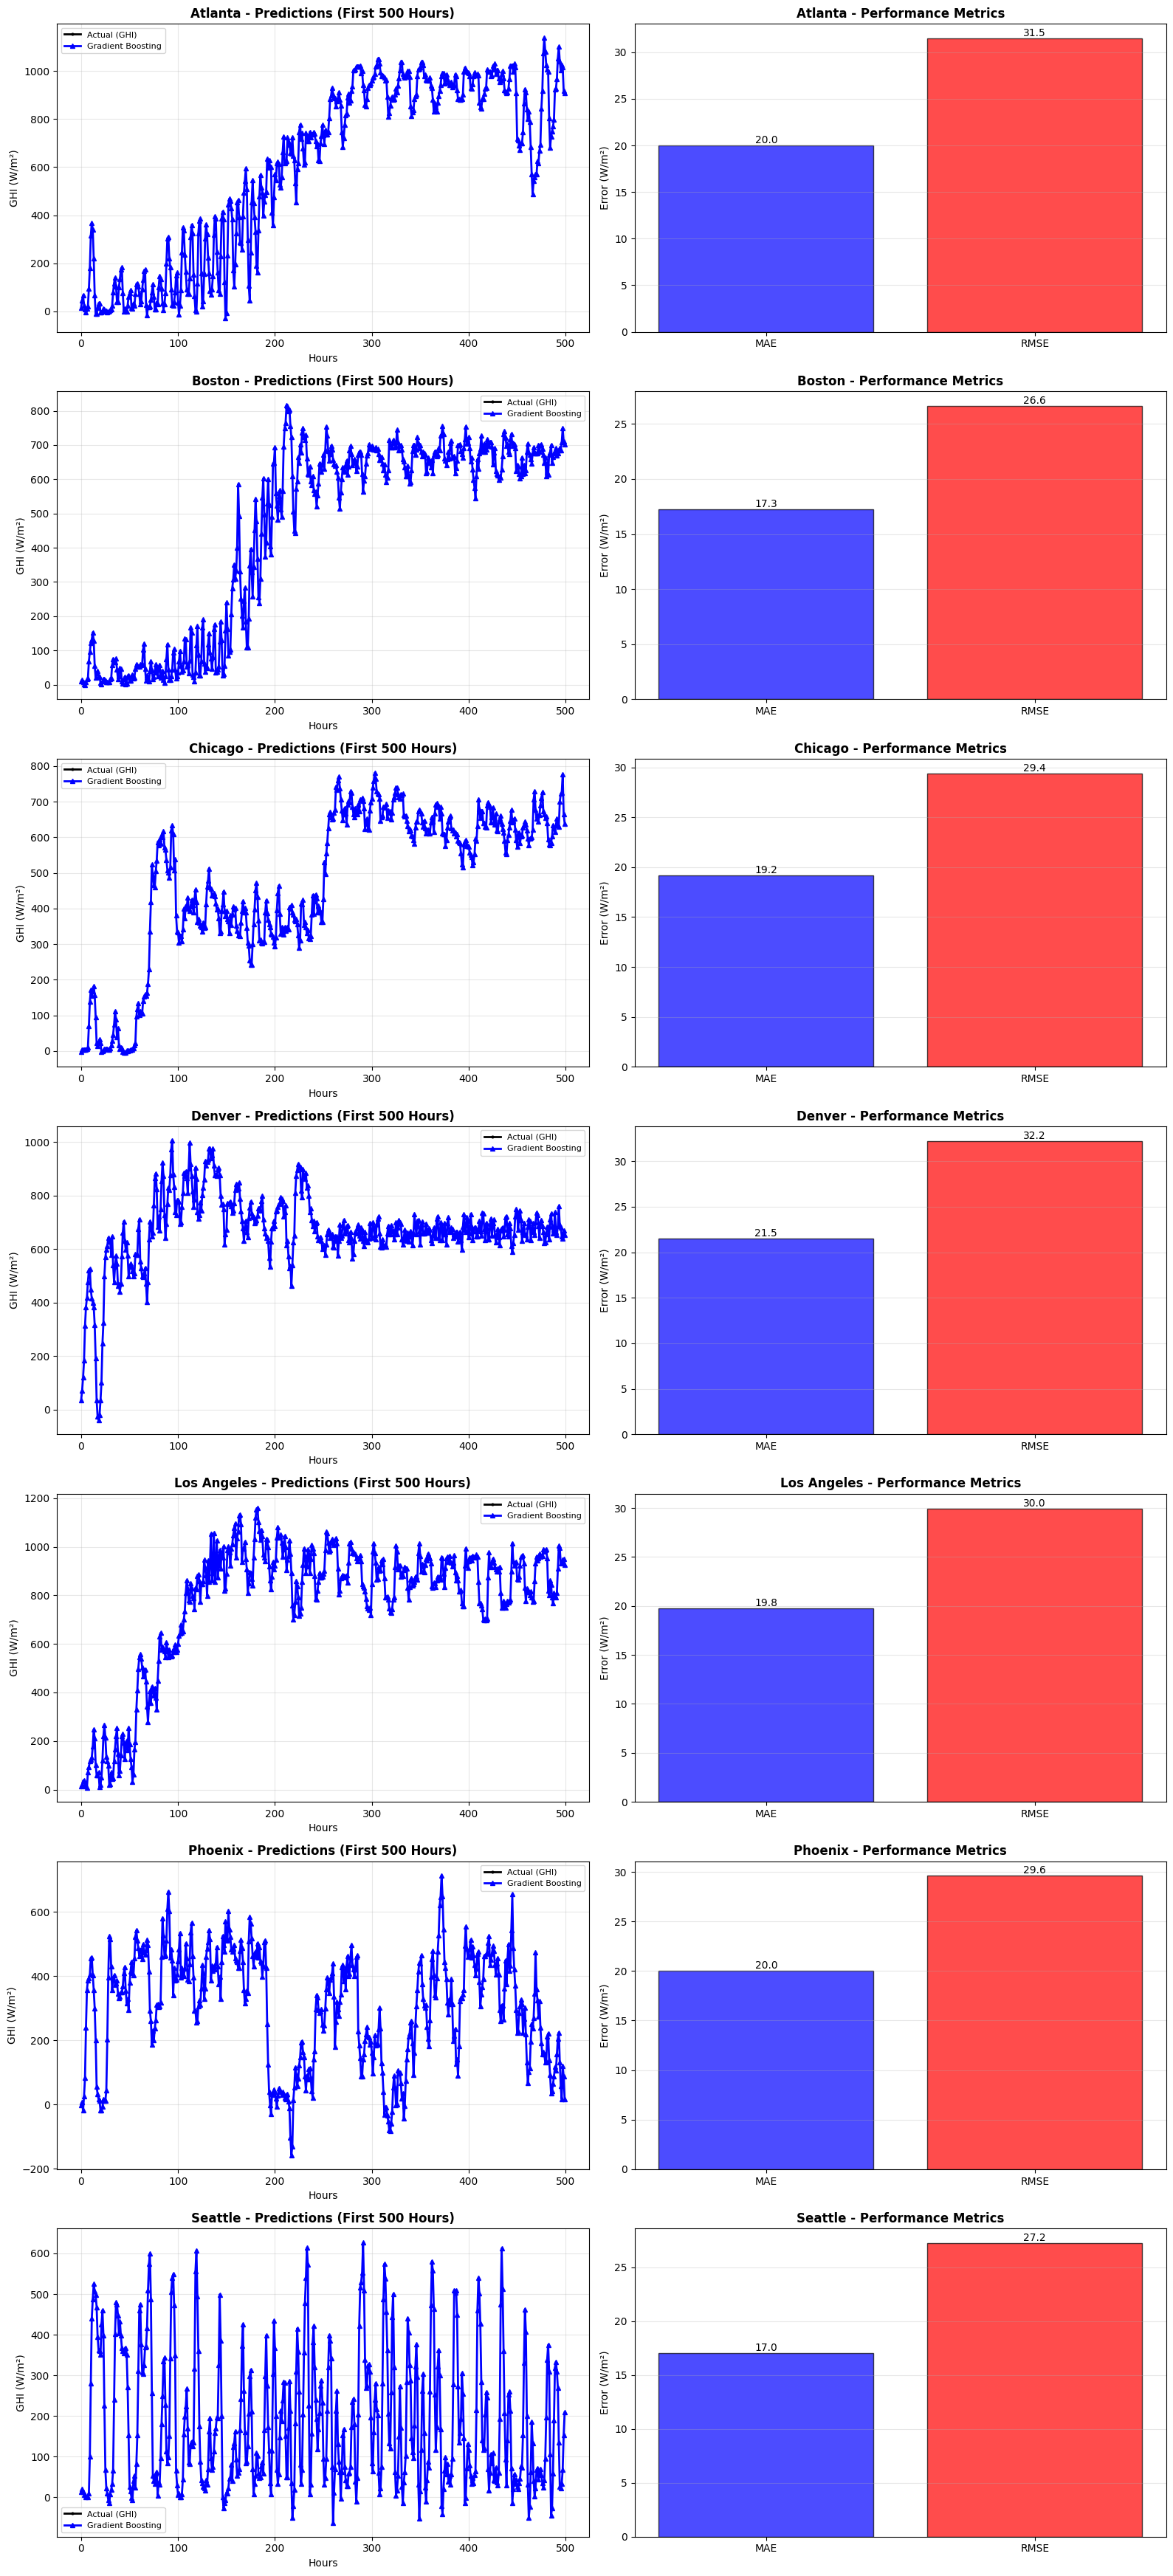

In [24]:
print("\nGenerating visualizations...")

# Get unique cities
cities_list = sorted(results_df['city'].unique())
n_cities = len(cities_list)

# Create subplots for each city
fig, axes = plt.subplots(n_cities, 2, figsize=(16, 5*n_cities))

if n_cities == 1:
    axes = axes.reshape(1, -1)

for idx, city in enumerate(cities_list):
    city_data = results_df[results_df['city'] == city].copy()
    city_data = city_data.sort_values('date')
    
    # First 500 hours for clarity
    n_plot = min(500, len(city_data))
    hours = range(n_plot)
    
    # Subplot 1: Predictions for this city
    ax = axes[idx, 0]
    ax.plot(hours, city_data['actual_ghi'].values[:n_plot], 'o-', label='Actual (GHI)', linewidth=2, markersize=2, color='black')
    ax.plot(hours, city_data['forecasted_ghi'].values[:n_plot], '^-', label='Gradient Boosting', linewidth=2, markersize=4, color='blue')
    ax.set_xlabel('Hours'); ax.set_ylabel('GHI (W/m²)')
    ax.set_title(f'{city} - Predictions (First 500 Hours)', fontweight='bold')
    ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
    
    # Subplot 2: Metrics for this city
    ax = axes[idx, 1]
    mae = city_data['mae'].iloc[0]
    rmse = city_data['rmse'].iloc[0]
    ax.bar(['MAE', 'RMSE'], [mae, rmse], color=['blue', 'red'], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Error (W/m²)')
    ax.set_title(f'{city} - Performance Metrics', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(ax.patches, [mae, rmse]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('gradient_boosting_forecast_by_city.png', dpi=300, bbox_inches='tight')
print("✓ Saved: gradient_boosting_forecast_by_city.png")
plt.show()

## 8. Summary

In [25]:
print("="*50)
print("GRADIENT BOOSTING FORECAST SUMMARY (BY CITY)")
print("="*50)

for city in sorted(results_df['city'].unique()):
    city_data = results_df[results_df['city'] == city]
    mae = city_data['mae'].iloc[0]
    rmse = city_data['rmse'].iloc[0]
    mape = city_data['mape'].iloc[0]
    
    print(f"\n{city}:")
    print(f"  1. MODEL PERFORMANCE:")
    print(f"     MAE: {mae:.2f} W/m²")
    print(f"     RMSE: {rmse:.2f} W/m²")
    print(f"     MAPE: {mape:.2f}%")
    print(f"  2. FORECAST PERIOD:")
    print(f"     Start: {city_data['date'].min()}")
    print(f"     End: {city_data['date'].max()}")
    print(f"     Records: {len(city_data):,}")

print(f"\n" + "="*50)
print("OVERALL SUMMARY:")
print(f"  Total Cities: {len(results_df['city'].unique())}")
print(f"  Total Forecast Records: {len(results_df):,}")
print(f"  Average MAE: {results_df.groupby('city')['mae'].first().mean():.2f} W/m²")
print(f"  Average RMSE: {results_df.groupby('city')['rmse'].first().mean():.2f} W/m²")
print("="*50)

GRADIENT BOOSTING FORECAST SUMMARY (BY CITY)

Atlanta:
  1. MODEL PERFORMANCE:
     MAE: 20.02 W/m²
     RMSE: 31.48 W/m²
     MAPE: 22.20%
  2. FORECAST PERIOD:
     Start: 2025-01-01 00:00:00
     End: 2025-03-31 23:00:00
     Records: 2,160

Boston:
  1. MODEL PERFORMANCE:
     MAE: 17.27 W/m²
     RMSE: 26.63 W/m²
     MAPE: 20.12%
  2. FORECAST PERIOD:
     Start: 2025-01-01 00:00:00
     End: 2025-03-31 23:00:00
     Records: 2,160

Chicago:
  1. MODEL PERFORMANCE:
     MAE: 19.19 W/m²
     RMSE: 29.38 W/m²
     MAPE: 24.68%
  2. FORECAST PERIOD:
     Start: 2025-01-01 00:00:00
     End: 2025-03-31 23:00:00
     Records: 2,160

Denver:
  1. MODEL PERFORMANCE:
     MAE: 21.48 W/m²
     RMSE: 32.23 W/m²
     MAPE: 21.15%
  2. FORECAST PERIOD:
     Start: 2025-01-01 00:00:00
     End: 2025-03-31 23:00:00
     Records: 2,160

Los Angeles:
  1. MODEL PERFORMANCE:
     MAE: 19.76 W/m²
     RMSE: 29.96 W/m²
     MAPE: 16.90%
  2. FORECAST PERIOD:
     Start: 2025-01-01 00:00:00
     End

## 9. Save Forecasts

In [26]:
# Save forecasts to parquet with city information
print('Saving forecasts to parquet...')
try:
    # Create forecast dataframe with city information
    forecast_df = pd.DataFrame({
        'city': [r['city'] for r in all_results],
        'date': [r['date'] for r in all_results],
        'actual_ghi': [r['actual_ghi'] for r in all_results],
        'forecasted_ghi': [r['forecasted_ghi'] for r in all_results],
        'mae': [r['mae'] for r in all_results],
        'rmse': [r['rmse'] for r in all_results],
        'mape': [r['mape'] for r in all_results]
    })
    
    forecast_df.to_parquet('gradient_boosting_forecasts_by_city.parquet', index=False)
    print('✓ Saved: gradient_boosting_forecasts_by_city.parquet')
    print(f'  Total rows: {len(forecast_df):,}')
    print(f'  Cities: {forecast_df["city"].nunique()}')
    print(f'  Date range: {forecast_df["date"].min()} to {forecast_df["date"].max()}')
except Exception as e:
    print('ERROR writing parquet:', e)

Saving forecasts to parquet...
✓ Saved: gradient_boosting_forecasts_by_city.parquet
  Total rows: 15,120
  Cities: 7
  Date range: 2025-01-01 00:00:00 to 2025-03-31 23:00:00


In [27]:
import pandas as pd

# Load and display forecasts by city
try:
    df_forecasts = pd.read_parquet('gradient_boosting_forecasts_by_city.parquet')
    print("3-MONTH FORECASTS BY CITY")
    print("="*80)
    print(f"Total records: {len(df_forecasts):,}")
    print(f"\nSample data:")
    print(df_forecasts.head(10))
    
    print(f"\n\nSummary by City:")
    print(df_forecasts.groupby('city').agg({
        'date': ['min', 'max', 'count'],
        'forecasted_ghi': ['mean', 'min', 'max'],
        'mae': 'first',
        'rmse': 'first',
        'mape': 'first'
    }).round(2))
except FileNotFoundError:
    print("File not found. Run the model training cells first.")
except Exception as e:
    print(f"Error: {e}")

3-MONTH FORECASTS BY CITY
Total records: 15,120

Sample data:
      city                date  actual_ghi  forecasted_ghi        mae  \
0  Phoenix 2025-01-01 00:00:00         NaN       -2.440428  19.995869   
1  Phoenix 2025-01-01 01:00:00         NaN        7.197571  19.995869   
2  Phoenix 2025-01-01 02:00:00         NaN      -18.459994  19.995869   
3  Phoenix 2025-01-01 03:00:00         NaN       26.287866  19.995869   
4  Phoenix 2025-01-01 04:00:00         NaN       82.328222  19.995869   
5  Phoenix 2025-01-01 05:00:00         NaN      239.326689  19.995869   
6  Phoenix 2025-01-01 06:00:00         NaN      357.960752  19.995869   
7  Phoenix 2025-01-01 07:00:00         NaN      385.864779  19.995869   
8  Phoenix 2025-01-01 08:00:00         NaN      392.574295  19.995869   
9  Phoenix 2025-01-01 09:00:00         NaN      404.685619  19.995869   

        rmse       mape  
0  29.599509  14.973852  
1  29.599509  14.973852  
2  29.599509  14.973852  
3  29.599509  14.973852  
4  2

In [28]:
df = pd.read_parquet('gradient_boosting_forecasts.parquet')
print(df.tail())

                    date  forecasted_ghi
2155 2024-12-31 19:30:00       46.624132
2156 2024-12-31 20:30:00       18.104044
2157 2024-12-31 21:30:00       -4.450759
2158 2024-12-31 22:30:00       52.207476
2159 2024-12-31 23:30:00       89.008815
